In [12]:
!pip install git+https://github.com/pycaret/pycaret.git@master --upgrade

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-p0oyj8ol
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-p0oyj8ol
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [13]:
from pycaret.classification import *
import pandas as pd

# Load final model
final_model = load_model('Bank_Term_Deposit_LightGBM_Final')

Transformation Pipeline and Model Successfully Loaded


In [14]:
test_df = pd.read_csv('test.csv')
test_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown


In [15]:
test_predictions = predict_model(final_model, data=test_df)
test_predictions.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,prediction_label,prediction_score
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,0.9562
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,0.9880
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,0.9706
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,0.9955
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,0.9981


In [32]:
test_predictions[['prediction_label','prediction_score']]

,prediction_label,prediction_score
0,no,0.9562
1,no,0.9880
2,no,0.9706
3,no,0.9955
4,no,0.9981
...,...,...
4516,no,0.9830
4517,no,0.9995
4518,no,0.9945
4519,no,0.9092


In [36]:
# เลือกลูกค้าที่มีโอกาสสูง
high_potential = test_predictions[
    (test_predictions['prediction_label'] == 'yes') &
    (test_predictions['prediction_score'] >= 0.7)
]

high_potential.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,prediction_label,prediction_score
30,68,retired,divorced,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes,0.7318
40,38,management,single,tertiary,no,11971,yes,no,unknown,17,nov,609,2,101,3,failure,yes,0.7402
49,61,admin.,married,unknown,no,4629,yes,no,cellular,27,jan,181,1,92,1,success,yes,0.7835
70,37,management,married,tertiary,no,0,no,no,cellular,16,jul,268,2,182,3,success,yes,0.8642
98,36,blue-collar,divorced,secondary,no,2843,no,no,cellular,12,feb,473,1,182,1,success,yes,0.8782


In [18]:
high_potential.to_csv('Target_Customers_Term_Deposit.csv', index=False)

In [19]:
out = predict_model(final_model, data=test_df)

out['prediction_label'].value_counts()
out['prediction_score'].describe()

,prediction_score
count,4521.000000
mean,0.911443
std,0.138537
min,0.500600
25%,0.886400
50%,0.987700
75%,0.996600
max,0.999800


# Test กับข้อมูลที่มี y

In [20]:
from pycaret.classification import *
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

final_model = load_model('Bank_Term_Deposit_LightGBM_Final')
eval_df = pd.read_csv('test_y.csv')
out = predict_model(final_model, data=eval_df)
y_eval = eval_df['y']

# ประเมินผล
print(classification_report(y_eval, out['prediction_label']))
print(confusion_matrix(y_eval, out['prediction_label']))

Transformation Pipeline and Model Successfully Loaded
              precision    recall  f1-score   support

          no       0.95      0.97      0.96      4000
         yes       0.72      0.58      0.64       521

    accuracy                           0.93      4521
   macro avg       0.83      0.78      0.80      4521
weighted avg       0.92      0.93      0.92      4521

[[3883  117]
 [ 218  303]]


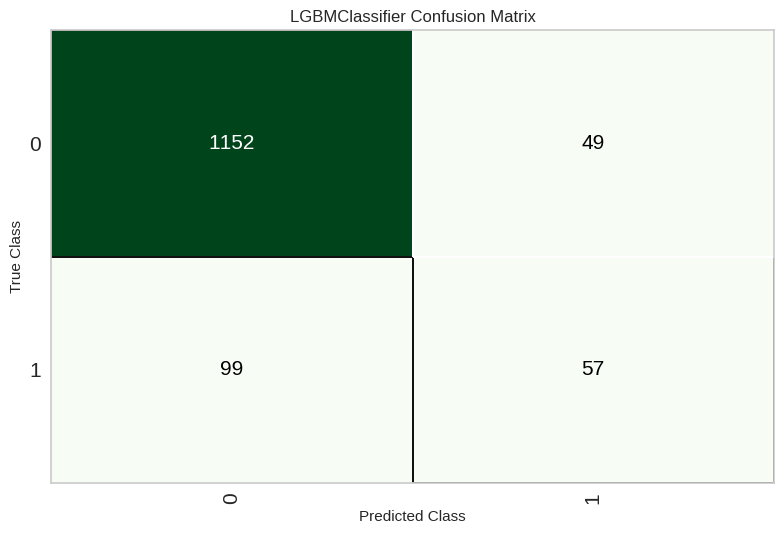

In [31]:
plot_model(final_model, plot='confusion_matrix')

In [25]:
test_df = pd.read_csv("test_y.csv")   # dataset ตอน train โมเดล

In [27]:
from pycaret.classification import *

setup(
    data=test_df,
    target="y",
    session_id=8717

)

,Description,Value
0,Session id,8717
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(4521, 17)"
5,Transformed data shape,"(4521, 49)"
6,Transformed train set shape,"(3164, 49)"
7,Transformed test set shape,"(1357, 49)"
8,Numeric features,7
9,Categorical features,9


Transformation Pipeline and Model Successfully Loaded


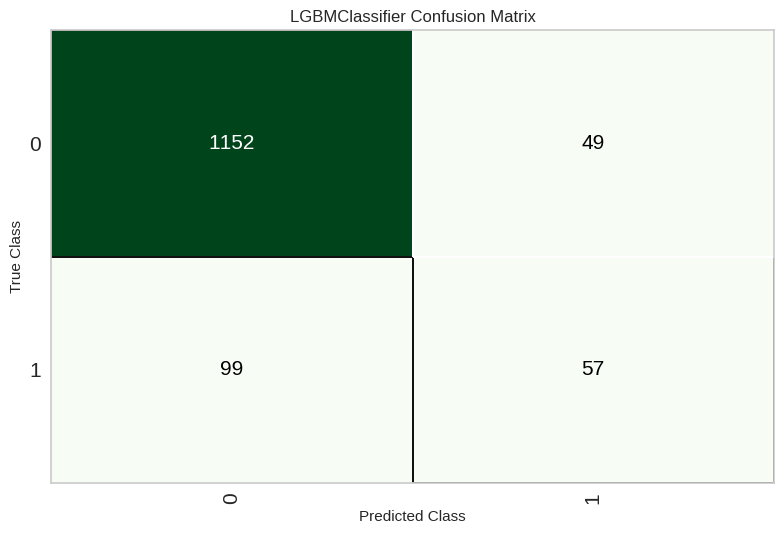

In [29]:
final_model = load_model('Bank_Term_Deposit_LightGBM_Final')

plot_model(final_model, plot='confusion_matrix')
# plot_model(final_model, plot='pr')
# plot_model(final_model, plot='auc')
# plot_model(final_model, plot='feature')